# Actividad 4

# Ejercicio 2

Número de órbitas: 450


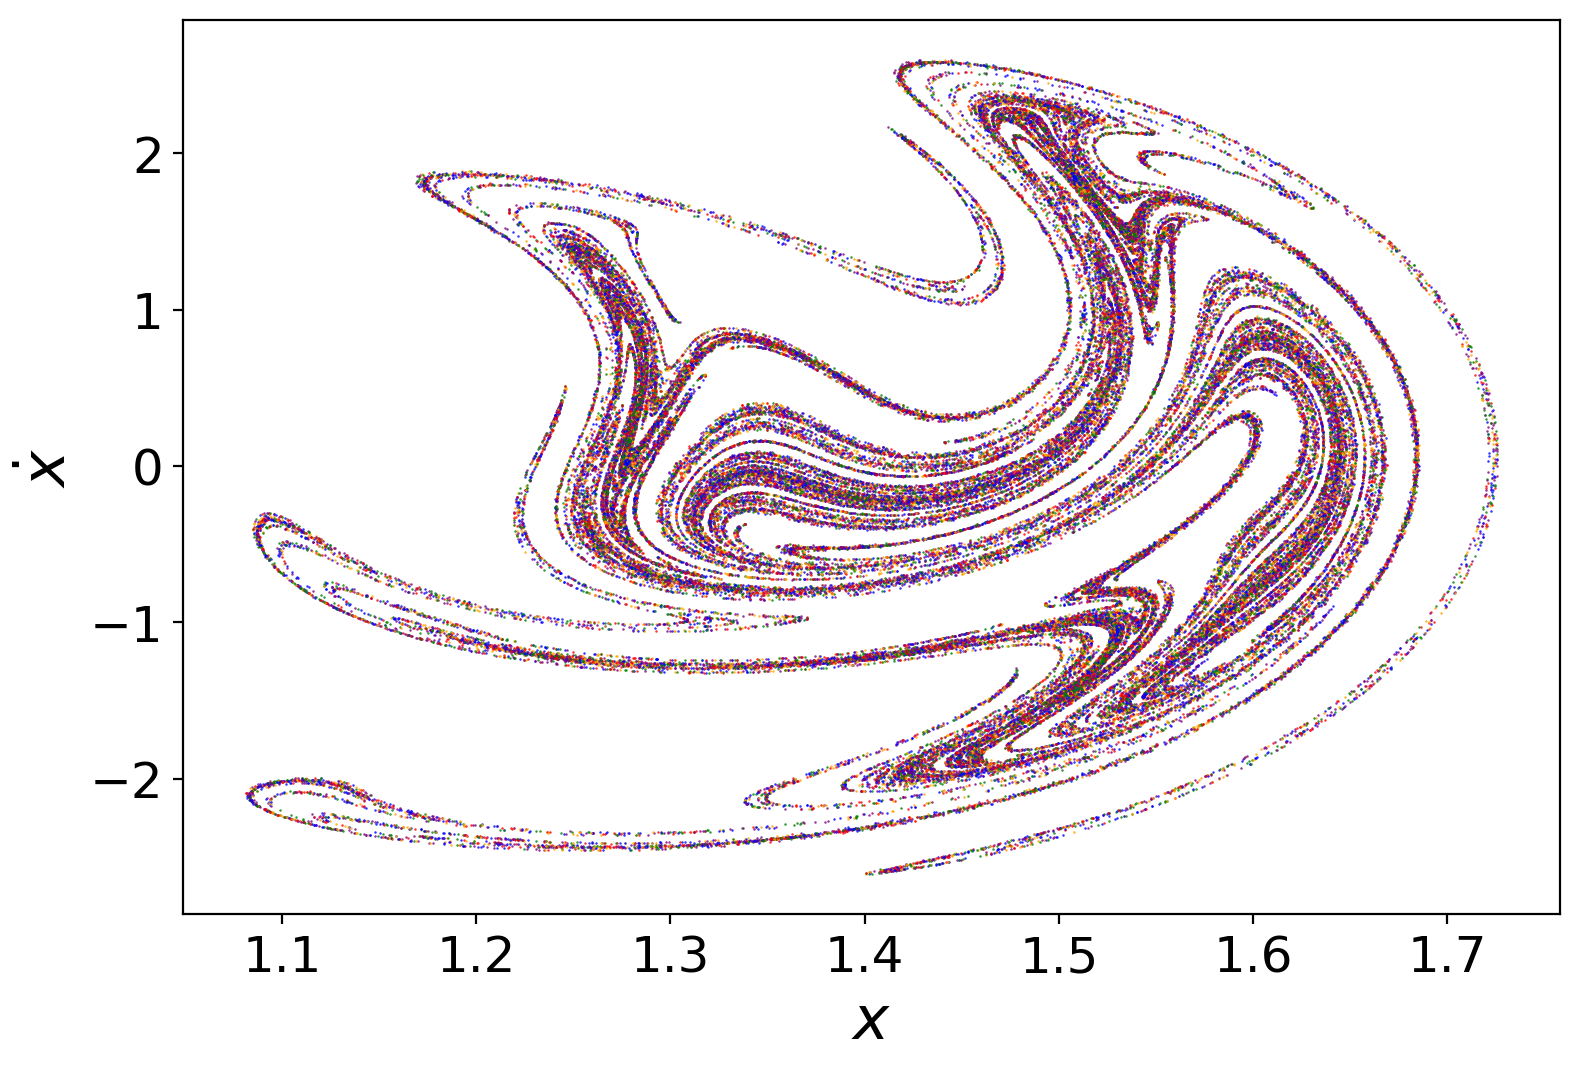

In [12]:
import numpy as np
from numpy import cos, pi
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# System parameters (Ejercicio 2)
# -----------------------------------------------------------
delta = 0.02
alpha = -1.0
beta = 5.0
gamma = 8.0
omega = 0.5

T = 2 * pi / omega         # Periodo de la fuerza externa

# -----------------------------------------------------------
# Initial conditions: grid adaptado a la Fig. 1-(a)
# -----------------------------------------------------------
x0_values = np.linspace(1.1, 1.7, 30)
v0_values = np.linspace(-2.5, 2.5, 15)
X0, V0 = np.meshgrid(x0_values, v0_values)
x0_flat = X0.ravel()
v0_flat = V0.ravel()
n_orbits = len(x0_flat)
print(f"Número de órbitas: {n_orbits}")

y = np.concatenate([x0_flat, v0_flat])

# -----------------------------------------------------------
# Method parameters
# -----------------------------------------------------------
Trans = 200          # Períodos transitorios a descartar
Nperiods = 1000      # Períodos totales de simulación
steps_per_T = 300    # Resolución de pasos por período T
dt = T / steps_per_T

# -----------------------------------------------------------
# Dynamics: Forced Duffing oscillator
# -----------------------------------------------------------
def dyn(t, y_state):
    x = y_state[:n_orbits]
    v = y_state[n_orbits:]
    dx = v
    dv = -delta * v + alpha * x - beta * x**3 + gamma * cos(omega * t)
    return np.concatenate([dx, dv])

# -----------------------------------------------------------
# Fourth-order Runge-Kutta method
# -----------------------------------------------------------
def rk4(f, t, y_state, h):
    k1 = h * f(t, y_state)
    k2 = h * f(t + h/2, y_state + k1/2)
    k3 = h * f(t + h/2, y_state + k2/2)
    k4 = h * f(t + h, y_state + k3)
    return y_state + (k1 + 2*k2 + 2*k3 + k4) / 6

# -----------------------------------------------------------
# Stroboscopic storage setup
# -----------------------------------------------------------
n_saved = Nperiods - Trans + 1
x_strobe = np.empty((n_saved, n_orbits))
v_strobe = np.empty((n_saved, n_orbits))
save_index = 0

total_steps = Nperiods * steps_per_T

# -----------------------------------------------------------
# Integration and Stroboscopic Sampling
# -----------------------------------------------------------
for step in range(total_steps):
    current_time = step * dt
    y = rk4(dyn, current_time, y, dt)
    
    completed_period = (step + 1) // steps_per_T
    if (step + 1) % steps_per_T == 0:
        if completed_period >= Trans:
            x_strobe[save_index] = y[:n_orbits]
            v_strobe[save_index] = y[n_orbits:]
            save_index += 1

# -----------------------------------------------------------
# Stroboscopic Map Plot (Ejercicio 2)
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6), dpi=200)

colors = ['red', 'orange', 'green', 'blue', 'purple']
for i in range(n_orbits):
    c = colors[i % len(colors)]
    ax.scatter(x_strobe[:, i], v_strobe[:, i], s=0.8, color=c, alpha=0.8, linewidths=0, rasterized=True)

ax.set_xlabel(r'$x$', fontsize=22)
ax.set_ylabel(r'$\dot{x}$', fontsize=22)
ax.tick_params(axis='both', labelsize=18)
ax.set_box_aspect(0.65)
plt.tight_layout()
plt.savefig("mapa_estroboscopico_1.png", format="png", bbox_inches="tight", dpi=300)
plt.show()

# Ejercicio 3

Número de órbitas: 450


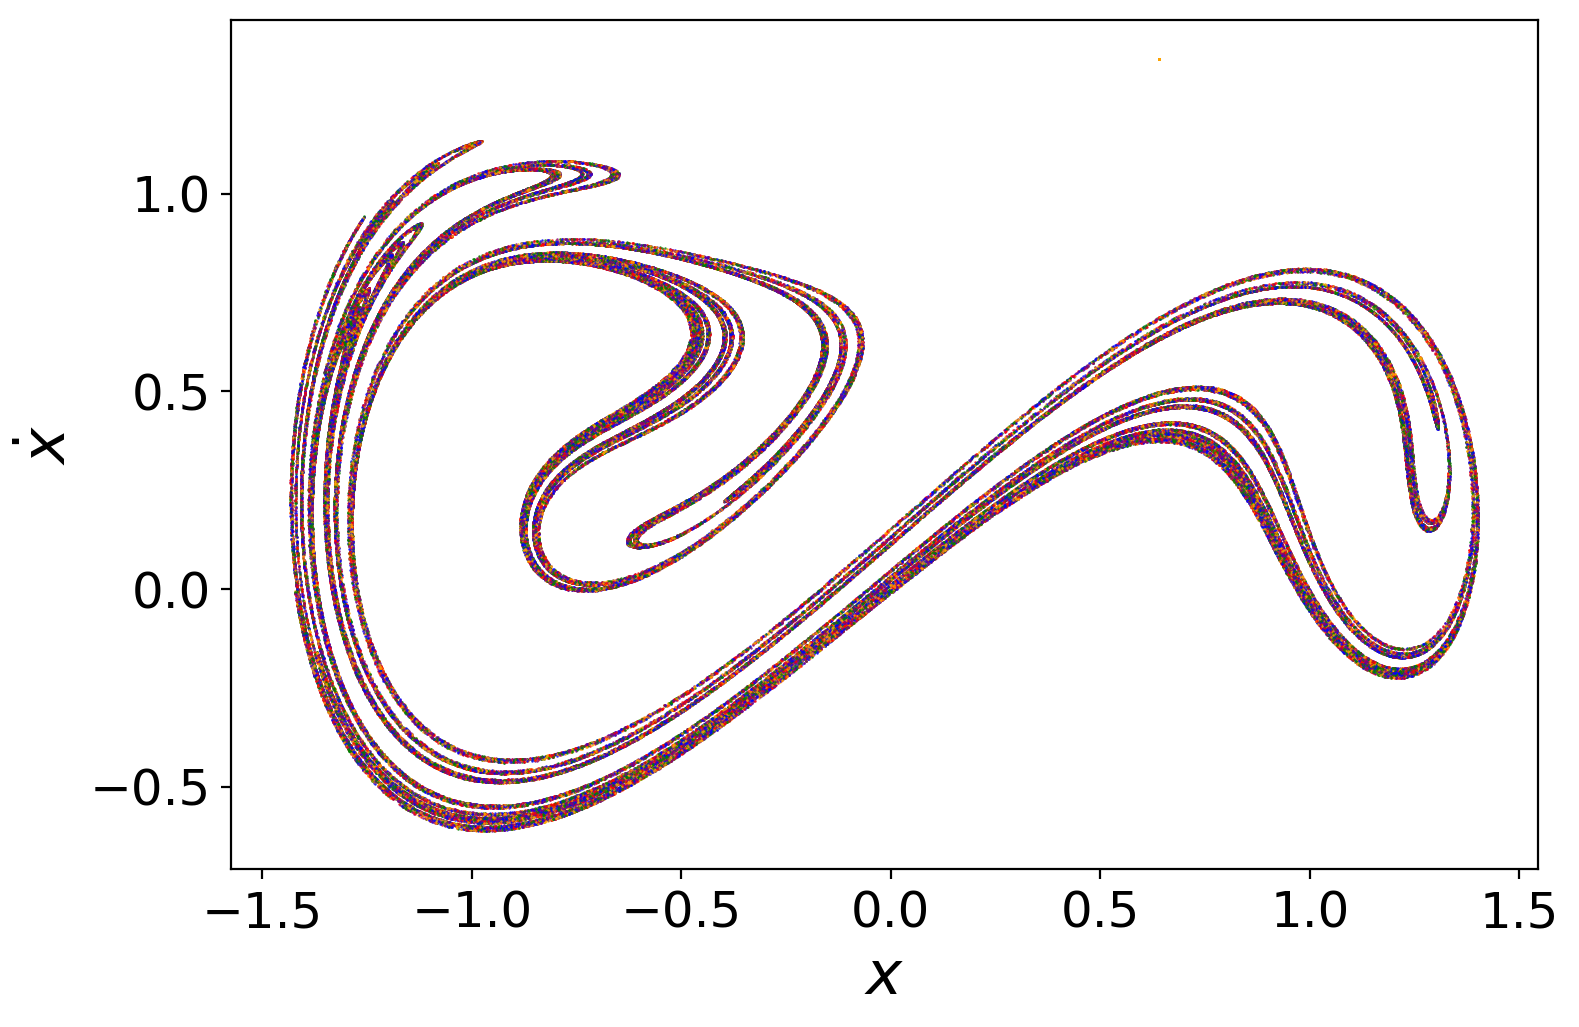

In [13]:
import numpy as np
from numpy import cos, pi
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# System parameters (Ejercicio 2)
# -----------------------------------------------------------
delta = 0.15
alpha = 1.0
beta = 1.0
gamma = 0.3
omega = 1

T = 2 * pi / omega         # Periodo de la fuerza externa

# -----------------------------------------------------------
# Initial conditions: grid adaptado a la Fig. 1-(a)
# -----------------------------------------------------------
x0_values = np.linspace(1.1, 1.7, 30)
v0_values = np.linspace(-2.5, 2.5, 15)
X0, V0 = np.meshgrid(x0_values, v0_values)
x0_flat = X0.ravel()
v0_flat = V0.ravel()
n_orbits = len(x0_flat)
print(f"Número de órbitas: {n_orbits}")

y = np.concatenate([x0_flat, v0_flat])

# -----------------------------------------------------------
# Method parameters
# -----------------------------------------------------------
Trans = 200          # Períodos transitorios a descartar
Nperiods = 1000      # Períodos totales de simulación
steps_per_T = 300    # Resolución de pasos por período T
dt = T / steps_per_T

# -----------------------------------------------------------
# Dynamics: Forced Duffing oscillator
# -----------------------------------------------------------
def dyn(t, y_state):
    x = y_state[:n_orbits]
    v = y_state[n_orbits:]
    dx = v
    dv = -delta * v + alpha * x - beta * x**3 + gamma * cos(omega * t)
    return np.concatenate([dx, dv])

# -----------------------------------------------------------
# Fourth-order Runge-Kutta method
# -----------------------------------------------------------
def rk4(f, t, y_state, h):
    k1 = h * f(t, y_state)
    k2 = h * f(t + h/2, y_state + k1/2)
    k3 = h * f(t + h/2, y_state + k2/2)
    k4 = h * f(t + h, y_state + k3)
    return y_state + (k1 + 2*k2 + 2*k3 + k4) / 6

# -----------------------------------------------------------
# Stroboscopic storage setup
# -----------------------------------------------------------
n_saved = Nperiods - Trans + 1
x_strobe = np.empty((n_saved, n_orbits))
v_strobe = np.empty((n_saved, n_orbits))
save_index = 0

total_steps = Nperiods * steps_per_T

# -----------------------------------------------------------
# Integration and Stroboscopic Sampling
# -----------------------------------------------------------
for step in range(total_steps):
    current_time = step * dt
    y = rk4(dyn, current_time, y, dt)
    
    completed_period = (step + 1) // steps_per_T
    if (step + 1) % steps_per_T == 0:
        if completed_period >= Trans:
            x_strobe[save_index] = y[:n_orbits]
            v_strobe[save_index] = y[n_orbits:]
            save_index += 1

# -----------------------------------------------------------
# Stroboscopic Map Plot (Ejercicio 2)
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6), dpi=200)

colors = ['red', 'orange', 'green', 'blue', 'purple']
for i in range(n_orbits):
    c = colors[i % len(colors)]
    ax.scatter(x_strobe[:, i], v_strobe[:, i], s=0.8, color=c, alpha=0.8, linewidths=0, rasterized=True)

ax.set_xlabel(r'$x$', fontsize=22)
ax.set_ylabel(r'$\dot{x}$', fontsize=22)
ax.tick_params(axis='both', labelsize=18)
ax.set_box_aspect(0.65)
plt.tight_layout()
plt.savefig("mapa_estroboscopico_2.png", format="png", bbox_inches="tight", dpi=300)
plt.show()